# Statistical insights

In [10]:
import pickle as pkl
import math
from scipy.spatial.distance import cdist
import time
import numpy as np
import matplotlib.pyplot as plt
import importlib, sys, os

from scipy.spatial.distance import cdist

from sklearn.manifold import TSNE

import random
random.seed(42)

# Import Data

In [11]:
parent_folder = "nanos_networkx_small"
folders = [name for name in os.listdir(parent_folder) 
           if os.path.isdir(os.path.join(parent_folder, name))]

print(len(folders))

43


In [12]:
cwd = os.getcwd()
print(cwd)

/Users/laurofoletti/Documents/AML/P00_proteins/gradient_optimization


# Protein class definition

In [13]:
if 'classes.proteins' in sys.modules: importlib.reload(sys.modules['classes.proteins'])
from classes.proteins import *

# Database generation

In [14]:
random.seed(42)

PROTEINS = Database()

chunk_length = 50

for folder in folders:
    filename = f"{cwd}/{parent_folder}/{folder}/{folder}{folder[-2:]}_atoms.pkl"
    with open(filename, 'rb') as f:
        try:
            data = pkl.load(f)
            protein = Protein(data)
            if protein.len < 200:
                PROTEINS.append(protein)
            else:
                print (folder, 'refused, length', protein.len)
        except Exception as e:
            print (folder, 'corrupted')

PROTEINS.randomize
print (PROTEINS.len, 'proteins in store')

43 proteins in store


In [15]:
UNIQUE_AA = set()
for protein in PROTEINS:
    UNIQUE_AA.update(protein.aa)
UNIQUE_AA.update(['NUL'])
print(f"Unique amino acids in database : {len(UNIQUE_AA)}")

lengths = [protein.len for protein in PROTEINS]
print (lengths[:10])
min_len = min(lengths)

protein = PROTEINS[0]
sequences_oh = [protein.get_oh(list(UNIQUE_AA)) for protein in PROTEINS]
sequences_oh[0].shape

Unique amino acids in database : 21
[120, 129, 132, 127, 115, 135, 121, 132, 116, 119]


(120, 21)

In [16]:
def get_rolling_dist(seq, min_len):
    output = np.zeros((min_len, len(seq[0]))).astype(np.float32)
    for i in range(min_len):
        subseq = seq[i : i+len(seq)-min_len]
        total = np.sum(subseq)
        if total == 0:
            res = np.zeros_like(subseq[0])
        else:
            res = np.sum(subseq, axis=0) / (total + 1e-8)
        output[i] = res
    return output

embeddings = np.array([get_rolling_dist(s, min_len-1) for s in sequences_oh])
embeddings.shape

(43, 101, 21)

In [17]:
X = embeddings.reshape(embeddings.shape[0], -1)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

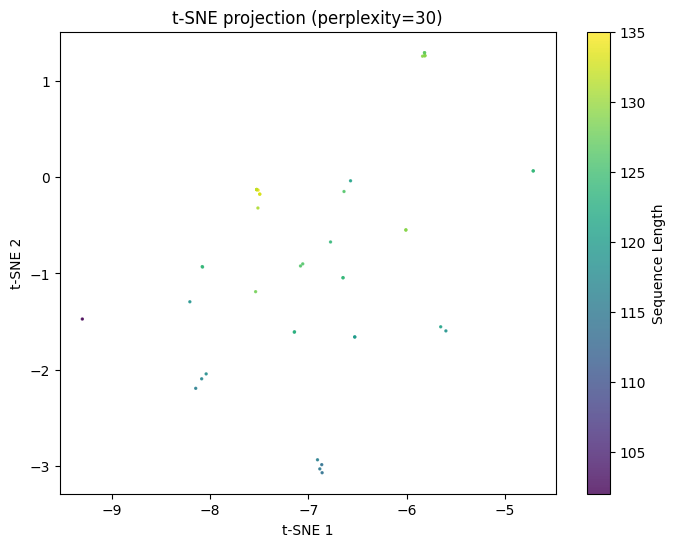

In [18]:
# Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=lengths, cmap='viridis', s=2, alpha=0.8)
plt.colorbar(sc, label="Sequence Length")
plt.title("t-SNE projection (perplexity=30)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(False)
plt.show()

In [19]:
def point_importance(curve):
    """Compute importance (angle-based) for each point in a 3D curve."""
    importance = np.zeros(len(curve))
    for i in range(1, len(curve)-1):
        a, b, c = curve[i-1], curve[i], curve[i+1]
        ba = a - b
        bc = c - b
        cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
        importance[i] = 1 - cosine_angle  # Higher = sharper turn
    return importance

def simplify_fixed_points(curve, num_points):
    """Simplify a 3D curve to `num_points` based on point importance."""
    if num_points >= len(curve):
        return curve

    importance = point_importance(curve)
    
    # Keep endpoints
    idx = [0, len(curve)-1]
    
    # Pick top-k other important points
    remaining = num_points - 2
    top_indices = np.argsort(importance)[::-1][:remaining]
    
    idx += top_indices.tolist()
    idx = np.sort(np.unique(idx))  # Ensure increasing order and uniqueness

    return curve[idx]

n_points = 40
simplified_curves = [simplify_fixed_points(np.array(protein.ca), 50) for protein in PROTEINS]
dist_matrices = [cdist(curve, curve, metric='euclidean') for curve in simplified_curves]
structure_embeddings = np.array(dist_matrices)

In [20]:
str_X = structure_embeddings.reshape(structure_embeddings.shape[0], -1)
str_tsne = TSNE(n_components=2, perplexity=30, random_state=42)
str_X_tsne = str_tsne.fit_transform(str_X)

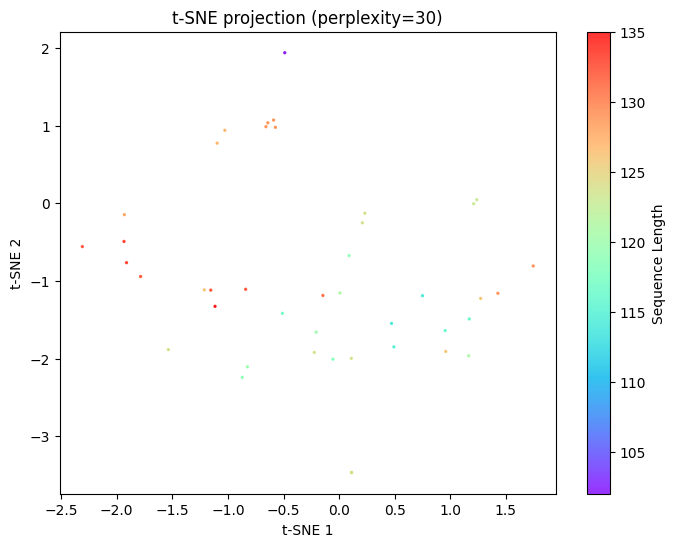

In [21]:
# Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(str_X_tsne[:, 0], str_X_tsne[:, 1], c=lengths, cmap='rainbow', s=2, alpha=0.8)
plt.colorbar(sc, label="Sequence Length")
plt.title("t-SNE projection (perplexity=30)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(False)
plt.show()